#Engineers Management Report

## Section 1: Project Definition

Industry: A staff augmentation company that provides training for engineers and then deploy them to client companies for services. In this project, services focus on aircon services, electrical work and telecom infrastructure setup.

### Goals

1. Engineer Productivity Analysis: To provide actionable insights on engineer productivity, identifying areas of strength and opportunities for improvement.

2. Customer Satisfaction Evaluation: To assess customer satisfaction with engineer services, highlighting factors influencing satisfaction and potential areas for growth.



## Section 2: Dataset

3 datasets from multiple sources:
1. Engineers data in excel (HR data)
2. Client data in excel format (CRM data)
3. Ticket data in CSV format (Ticketing data)
 - These data are synthetic data generated by Meta AI

 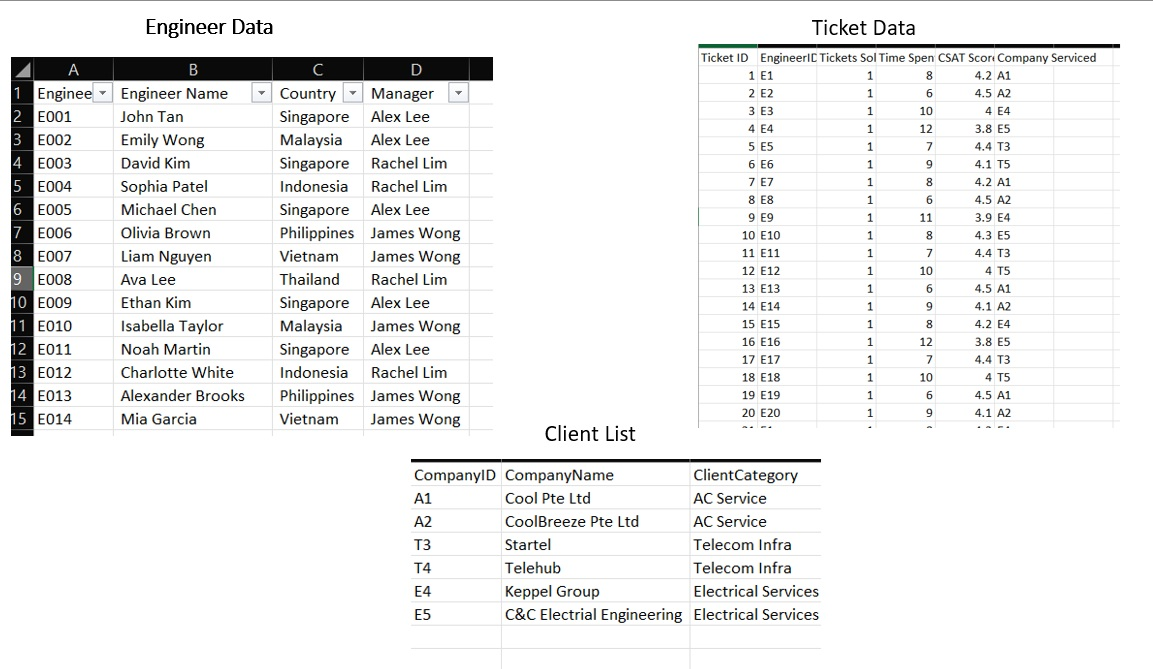


**Section 3: Data Engineering**

Performed several steps in data engineering

Data Exploration:
Understand if there is  nulls, duplicates and also the unreasonable values.

Data Cleaning:
Remove duplicate values, correct unreasonble values.

Read the Engineer dataset in excel format

In [1]:
import pandas as pd

In [14]:
df_engineer = pd.read_excel('/content/Engineer Data set.xlsx', header=0)
display(df_engineer.head())

,Engineer ID,Engineer Name,Country,Manager
0,E001,John Tan,Singapore,Alex Lee
1,E002,Emily Wong,Malaysia,Alex Lee
2,E003,David Kim,Singapore,Rachel Lim
3,E004,Sophia Patel,Indonesia,Rachel Lim
4,E005,Michael Chen,Singapore,Alex Lee


Perform data exploration by generating general overview of engineer data. Check number of row and null values and data type

There is no missing data

In [15]:
df_engineer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Engineer ID      102 non-null    object
 1    Engineer Name   102 non-null    object
 2    Country         102 non-null    object
 3    Manager         102 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


Check for duplicate in Engineer dataset. In this case there are 2 duplicate rows.

In [16]:
print(f"Number of duplicate rows: {df_engineer.duplicated().sum()}")

Number of duplicate rows: 2


Display the duplicates before deleting

In [17]:
duplicate_rows = df_engineer[df_engineer.duplicated(keep=False)]
display(duplicate_rows)

,Engineer ID,Engineer Name,Country,Manager
89,E090,Benjamin Lewis,Singapore,Alex Lee
90,E090,Benjamin Lewis,Singapore,Alex Lee
100,E100,Christopher Patel,Vietnam,James Wong
101,E100,Christopher Patel,Vietnam,James Wong


Remove duplicates

In [18]:
df_engineer = df_engineer.drop_duplicates()
print(f"New shape after removing duplicates: {df_engineer.shape}")

New shape after removing duplicates: (100, 4)


Read the ticket data in CSV format

In [19]:
df_ticket = pd.read_csv('/content/ticket.csv')
display(df_ticket.head())

,Ticket ID,EngineerID,Tickets Solved,Time Spent (hours),CSAT Score,Company Serviced
0,1,E1,1,8.0,4.2,A1
1,2,E2,1,6.0,4.5,A2
2,3,E3,1,10.0,4.0,E4
3,4,E4,1,12.0,3.8,E5
4,5,E5,1,7.0,4.4,T3


Check for duplidate in ticket data.
There is no duplicate data

In [20]:
print(f"Number of duplicate rows in df_ticket: {df_ticket.duplicated().sum()}")

Number of duplicate rows in df_ticket: 0


Read client data in excel format

There is no missing data

In [21]:
df_client = pd.read_excel('/content/Client.xlsx')
display(df_client.head())
df_client.info()

,CompanyID,CompanyName,ClientCategory
0,A1,Cool Pte Ltd,AC Service
1,A2,CoolBreeze Pte Ltd,AC Service
2,T3,Startel,Telecom Infra
3,T4,Telehub,Telecom Infra
4,E4,Keppel Group,Electrical Services


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CompanyID       6 non-null      object
 1   CompanyName     6 non-null      object
 2   ClientCategory  6 non-null      object
dtypes: object(3)
memory usage: 276.0+ bytes


In [22]:
import pandas as pd

# Read df_ticket to inspect columns if necessary
df_ticket = pd.read_csv('/content/ticket.csv')

# --- Debugging: Print column names to identify the correct 'Engineer ID' column ---
print("df_ticket columns:")
print(df_ticket.columns)
# --- End Debugging ---

# Aggregate ticket data to get total time spent and average CSAT per engineer
df_engineer_ticket_metrics = df_ticket.groupby('EngineerID').agg(
    {'Time Spent (hours)': 'sum',
     'CSAT Score': 'mean'  # Assuming CSAT Score is directly the score, taking mean for avg
    }
).reset_index()

# Rename the CSAT Score column for clarity
df_engineer_ticket_metrics = df_engineer_ticket_metrics.rename(columns={'CSAT Score': 'CSAT Score (Avg)'})

# Display the aggregated metrics
print("Aggregated Engineer Ticket Metrics:")
display(df_engineer_ticket_metrics.head())

df_ticket columns:
Index(['Ticket ID', 'EngineerID', 'Tickets Solved', 'Time Spent (hours)',
       'CSAT Score', 'Company Serviced'],
      dtype='object')
Aggregated Engineer Ticket Metrics:


,EngineerID,Time Spent (hours),CSAT Score (Avg)
0,E1,76.0,4.050000
1,E10,54.0,4.300000
2,E11,64.0,4.114286
3,E12,55.0,4.257143
4,E13,62.0,4.142857


Add Total Time Spent column from ticket dataset to engineer dataset

In [23]:
# Re-initialize df_engineer from its original source and clean it
df_engineer = pd.read_excel('/content/Engineer Data set.xlsx', header=0) # Correctly load header from the first row
df_engineer = df_engineer.drop_duplicates()

# Strip whitespace from column names for df_engineer
df_engineer.columns = df_engineer.columns.str.strip()

# Ensure 'Engineer ID' column values are stripped of whitespace and are of string type in df_engineer
df_engineer['Engineer ID'] = df_engineer['Engineer ID'].astype(str).str.strip()

# Standardize 'Engineer ID' format in df_engineer to match df_engineer_ticket_metrics (e.g., 'E001' to 'E1')
df_engineer['Engineer ID'] = df_engineer['Engineer ID'].str.replace('E00', 'E', regex=False)
df_engineer['Engineer ID'] = df_engineer['Engineer ID'].str.replace('E0', 'E', regex=False) # In case of E01, E02 etc

# Ensure 'EngineerID' in df_engineer_ticket_metrics is also explicitly stripped and string type for robust merging
df_engineer_ticket_metrics['EngineerID'] = df_engineer_ticket_metrics['EngineerID'].astype(str).str.strip()

# --- DEBUGGING START ---
print(f"df_engineer['Engineer ID'] dtype: {df_engineer['Engineer ID'].dtype}")
print(f"df_engineer_ticket_metrics['EngineerID'] dtype: {df_engineer_ticket_metrics['EngineerID'].dtype}")
print(f"Unique Engineer IDs in df_engineer (first 5) (repr): {[repr(x) for x in df_engineer['Engineer ID'].unique()[:5]]}")
print(f"Unique Engineer IDs in df_engineer_ticket_metrics (first 5) (repr): {[repr(x) for x in df_engineer_ticket_metrics['EngineerID'].unique()[:5]]}")

# Check for common IDs before merging
common_ids = set(df_engineer['Engineer ID']) & set(df_engineer_ticket_metrics['EngineerID'])
print(f"Number of common Engineer IDs: {len(common_ids)}")
if len(common_ids) == 0:
    print("Warning: No common Engineer IDs found between df_engineer and df_engineer_ticket_metrics. This is unexpected if data overlaps.")
# --- DEBUGGING END ---

# Merge df_engineer with the aggregated df_engineer_ticket_metrics
df_engineer = pd.merge(df_engineer, df_engineer_ticket_metrics[['EngineerID', 'Time Spent (hours)', 'CSAT Score (Avg)']], left_on='Engineer ID', right_on='EngineerID', how='left')

# Drop the duplicate 'EngineerID' column from the merge if it exists
df_engineer.drop(columns=['EngineerID'], inplace=True)

# Rename 'Time Spent (hours)' to 'Time Spent on Ticket' for consistency with later code
df_engineer = df_engineer.rename(columns={'Time Spent (hours)': 'Time Spent on Ticket'})

print("df_engineer after merge with aggregated Time Spent on Ticket and CSAT Score:")
display(df_engineer.head())
print("\nColumns in df_engineer after merge:")
print(df_engineer.columns)
print("\ndf_engineer info after merge:")
df_engineer.info()

df_engineer['Engineer ID'] dtype: object
df_engineer_ticket_metrics['EngineerID'] dtype: object
Unique Engineer IDs in df_engineer (first 5) (repr): ["'E1'", "'E2'", "'E3'", "'E4'", "'E5'"]
Unique Engineer IDs in df_engineer_ticket_metrics (first 5) (repr): ["'E1'", "'E10'", "'E11'", "'E12'", "'E13'"]
Number of common Engineer IDs: 20
df_engineer after merge with aggregated Time Spent on Ticket and CSAT Score:


,Engineer ID,Engineer Name,Country,Manager,Time Spent on Ticket,CSAT Score (Avg)
0,E1,John Tan,Singapore,Alex Lee,76.0,4.050000
1,E2,Emily Wong,Malaysia,Alex Lee,54.0,4.400000
2,E3,David Kim,Singapore,Rachel Lim,74.0,3.942857
3,E4,Sophia Patel,Indonesia,Rachel Lim,54.0,4.300000
4,E5,Michael Chen,Singapore,Alex Lee,63.0,4.128571



Columns in df_engineer after merge:
Index(['Engineer ID', 'Engineer Name', 'Country', 'Manager',
       'Time Spent on Ticket', 'CSAT Score (Avg)'],
      dtype='object')

df_engineer info after merge:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Engineer ID           100 non-null    object 
 1   Engineer Name         100 non-null    object 
 2   Country               100 non-null    object 
 3   Manager               100 non-null    object 
 4   Time Spent on Ticket  20 non-null     float64
 5   CSAT Score (Avg)      20 non-null     float64
dtypes: float64(2), object(4)
memory usage: 4.8+ KB


Add a calculated column in the engineer dataset, productivity %

In [24]:
# Calculate productivity and add it as a new column
df_engineer['productivity'] = (df_engineer['Time Spent on Ticket'] / 160) * 100

# Create a copy of the DataFrame for display purposes to format 'productivity' as a percentage
df_display = df_engineer.copy()
df_display['productivity'] = df_display['productivity'].map('{:.2f}%'.format)

# Display the DataFrame head with the new column formatted as percentage
display(df_display.head())

,Engineer ID,Engineer Name,Country,Manager,Time Spent on Ticket,CSAT Score (Avg),productivity
0,E1,John Tan,Singapore,Alex Lee,76.0,4.050000,47.50%
1,E2,Emily Wong,Malaysia,Alex Lee,54.0,4.400000,33.75%
2,E3,David Kim,Singapore,Rachel Lim,74.0,3.942857,46.25%
3,E4,Sophia Patel,Indonesia,Rachel Lim,54.0,4.300000,33.75%
4,E5,Michael Chen,Singapore,Alex Lee,63.0,4.128571,39.38%


##Section 3: Data Visualization

### Productivity by Manager

To analyze the productivity of each team and provide actionable recommendations to improve overall team performance.

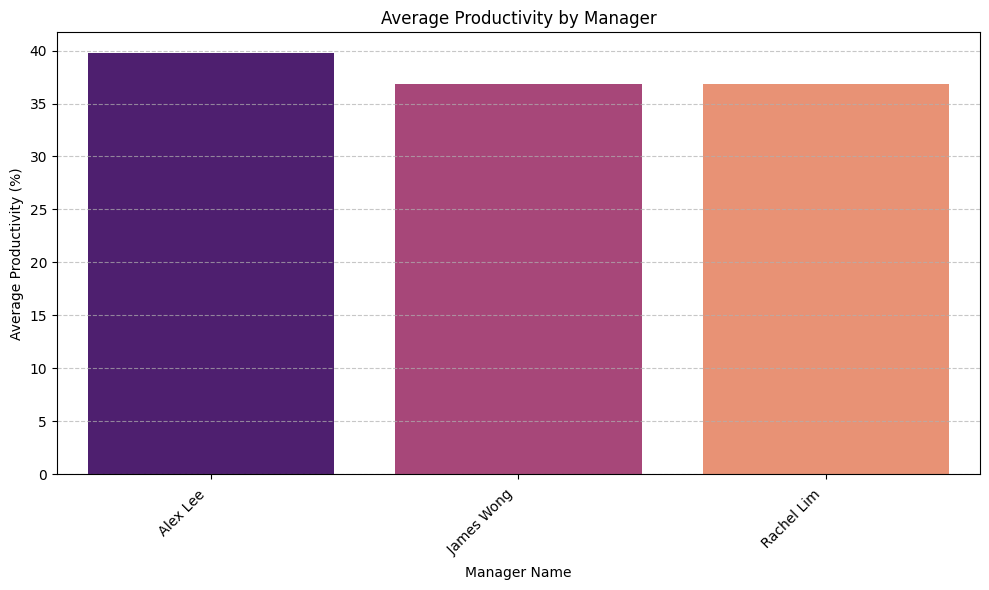

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate team productivity by grouping by 'Manager' and taking the mean of 'productivity'
team_productivity = df_engineer.groupby('Manager')['productivity'].mean().reset_index()
team_productivity = team_productivity.rename(columns={'Manager': 'Manager Name'}) # Ensure consistent column name

# Sort the team productivity values for better visualization
team_productivity = team_productivity.sort_values(by='productivity', ascending=False)

# Create the bar plot for team productivity
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Manager Name', y='productivity', data=team_productivity, palette='magma', hue='Manager Name', legend=False)
plt.title('Average Productivity by Manager')
plt.xlabel('Manager Name')
plt.ylabel('Average Productivity (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Find the manager with the lowest productivity
# (assuming team_productivity is already sorted, lowest will be the last one)
lowest_productivity_manager = team_productivity.iloc[-1]
manager_name_clean = lowest_productivity_manager['Manager Name'].strip() # Ensure it's stripped
productivity_value = lowest_productivity_manager['productivity']

# Get the x-coordinate for the bar
# Since the bar plot is created using the sorted team_productivity DataFrame, the x-position
# of the lowest productivity manager corresponds to its index in the sorted DataFrame.
bar_position = len(team_productivity) - 1

plt.tight_layout()
plt.show()

####Summary:

Team with highest productivity: Alex Lee's team

Team with lowest productivity: Rachel Lim's team

**Average CSAT Score by Country**

We can determine the country with the best customer satisfaction.

Recommendations:

Identify top-performing countries and conduct knowledge sharing sessions to
understand best practices.

Analyze countries with lower CSAT scores to identify areas for improvement.

Develop targeted training programs to address specific pain points and improve overall CSAT scores.

In [27]:
import plotly.express as px

# Calculate average CSAT Score by Country (if not already calculated)
# This ensures csat_by_country is available, even if previous cells were deleted.
# If csat_by_country is already defined in the kernel, this will use the existing one.
if 'csat_by_country' not in locals() or csat_by_country.empty:
    csat_by_country = df_engineer.groupby('Country')['CSAT Score (Avg)'].mean().reset_index()

fig = px.choropleth(csat_by_country,
                    locations="Country",
                    locationmode='country names',
                    color="CSAT Score (Avg)",
                    hover_name="Country",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title='Average CSAT Score by Country (Global)')
fig.show()

####Summary:
Country with the higest customer satisfaction: Malaysia

**Engineers Workload by Country**

Identify countries with high workload
(potential burnout).

Determine the need for hiring more manpower in specific country.

Identify countries with low workload (potential underutilization).

Optimize resource allocation to balance workload across countries.

Improve engineer productivity and job satisfaction


In [28]:
import plotly.express as px

# Aggregate 'Time Spent on Ticket' by Country
workload_by_country = df_engineer.groupby('Country')['Time Spent on Ticket'].sum().reset_index()

# Create the choropleth map for engineer workload
fig_workload = px.choropleth(workload_by_country,
                             locations="Country",
                             locationmode='country names',
                             color="Time Spent on Ticket",
                             hover_name="Country",
                             color_continuous_scale=px.colors.sequential.Viridis,
                             title='Engineer Workload (Total Time Spent on Ticket) by Country (Global)')
fig_workload.show()

####Summary:
Country with the higest workload: Indonesia

**Corelation Between Workload and Customer Satisfactory**

Too high workload leads to lower customer satisfaction

Recomendation:

Determine the optimal workload range that can lead to optimal customer satisfaction.

Monitor and adjust workloads to prevent burnout and maintain CSAT scores.

In [32]:
import plotly.express as px

# Create a copy to work with for plotting
df_plot = df_engineer.copy()

# Fill NaN values in 'Time Spent on Ticket' and 'CSAT Score (Avg)' with 0
# to ensure all engineers are plotted. Engineers with no data will appear at (0,0).
df_plot['Time Spent on Ticket'] = df_plot['Time Spent on Ticket'].fillna(0)
df_plot['CSAT Score (Avg)'] = df_plot['CSAT Score (Avg)'].fillna(0)

fig = px.scatter(df_plot, # Use the df_plot with filled NaNs
                   x='Time Spent on Ticket',
                   y='CSAT Score (Avg)',
                   size='Time Spent on Ticket', # Size of marker based on time spent
                   size_max=10, # Make the dots smaller for better visibility
                   hover_name='Engineer Name',
                   title='Relationship between Time Spent on Ticket and CSAT Score',
                   labels={
                       'Time Spent on Ticket': 'Time Spent on Ticket (hours)',
                       'CSAT Score (Avg)': 'Average CSAT Score'
                   }
                  )
fig.update_layout(showlegend=True, yaxis_range=[3.5, 4.6]) # Set y-axis to start from 3.5 and end at 4.6
fig.update_xaxes(range=[40, None]) # Set x-axis to start from 40
fig.show()

Summary:

There is a negative corelation between workload and customer satisfaction.

Excessive workloads may compromise service quality, leading to decreased customer satisfaction.

##Section 4: Extension of Use Cases of this Project

To analyze client data and identify high-demand service categories

Calculate demand metrics for each category, such as Revenue growth rate for strategic expansion

Develop a detailed expansion plan, including resource allocation and marketing strategies. Monitor progress and adjust plans as needed.



##Section 5: Reflection on Generative AI

1. Generative AI is designed to empower developers of all skill levels to code

2. Domain expert needs to regularly review AI-generated code to ensure accuracy and relevance. For example, running assert to validate the calculated value of productivity %

3. We can you use different Generative AI for different purpose. For example in this case, synthetic data generation was generated using MetaAI and Gemini was used for Python code generation

4. We need to give a clear prompting to Gemini on data visualization. For example, specify Gemini to set the appropriate scales for readablity on the scattered plot.

5. Generative AI has been very useful in refining documentation language, providing more professional and polished wording.